<a href="https://colab.research.google.com/github/slover1126/slover1126/blob/main/%ED%95%B8%EC%A6%88%EC%98%A8_%EB%A8%B8%EC%8B%A0%EB%9F%AC%EB%8B%9D_6%EC%9E%A5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**6장 결정트리**

**6.1 결정트리 학습과 시각화**

In [1]:
 #결정 트리를 이해하기 위한 모델 학습

from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

iris = load_iris(as_frame=True)
X_iris = iris.data[["petal length (cm)", "petal width (cm)"]].values
#print(X_iris)
y_iris = iris.target
#print(y_iris)

tree_clf = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf.fit(X_iris, y_iris)

DecisionTreeClassifier(max_depth=2, random_state=42)

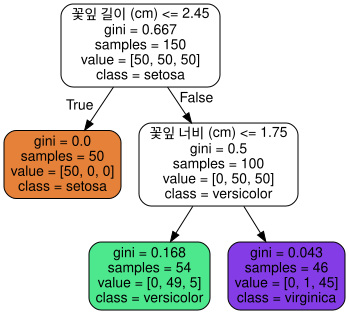

In [2]:
#시각화
from sklearn.tree import export_graphviz
from graphviz import Source
export_graphviz(
    tree_clf,
    out_file="iris_tree.dot",
    feature_names=["꽃잎 길이 (cm)","꽃잎 너비 (cm)"],
    class_names=iris.target_names,
    rounded=True, #노드 상자들 모양을 둥글게 깎아줌 (보기 이쁘게 만)
    filled=True #노드 상자에 색을 채워줌
)

Source.from_file("iris_tree.dot")

**6.2 예측**

*   앞서 학습한 트리를 해석
*    맨 위에 있는 상자를 **루트 노드** 라고 부르고, '꽃잎 길이 (cm) <= 2.45' 라는 조건을 걸어서 데이터들을 1차로 분류함
* 이때 '꽃잎 길이 (cm) <= 2.45' 가 True인 애들은 왼쪽 상자로 이동하고, 추가적인 탐색 조건이 없으므로 **리프 노드** 가 됨
*  한편,  False인 애들은 오른쪽 상자로 이동(깊이 = 1)되어 새로운 조건인 '꽃잎 너비 (cm) <= 1.75' 로 분류하고, 이떄 오른쪽 상자를 **분할 노드** 라고 함

*   다시 '꽃잎 너비 (cm) <= 1.75' 조건이 True 라면 왼쪽 상자로, False라면 오른쪽 상자로 분류함(이떄는 두 상자 모두 **리프 노드**가 됨)











*   위의 그림에서 **samples** 는 얼마나 많은 샘플들이 해당 노드에 들어있는지를 보여줌
*  **values**는 각 클래스별로 몇개의 샘플이 해당 노드에 들어있는지를 보여줌(루트노드의 values = [50,50,50]은 0,1,2번 클래스 모두 50개씩 들어있음을 의미)



*   맨 위의 **gini**는 지니 불순도를 측정한 값이고, 다음과 같이 계산됨
$$G_i = 1 - \sum_{k=1}^{n} p_{i,k}^2$$

*   $G_i$: 노드 $i$의 지니 불순도
*   $n$: 전체 클래스의 개수
*   $p_{i,k}$: 노드 $i$에 속한 전체 샘플 중 클래스 $k$에 속하는 샘플의 비율
*   한 노드 안의 샘플이 모두 같은 클래스인 경우 지니 불순도는 0임


*   예시) 깊이2 의 왼쪽 노드의 지니 불순도는 1-$(0/54)^2$-$(49/54)^2$-$(5/54)^2$ = 0.168 이 됨  
*   사이킷런은 이진 트리만 만드는 CART 알고리즘을 사용함(두 개의 자식 노드만 만듦). ID3 알고리즘은 둘 이상의 자식 노드를 만들 수 있음


*   직관적이고 결정방식을 이해하기 쉽기 떄문에 결정 트리는 **화이트박스 모델**  이라고 불림.










**6.3 클래스 확률 추정**


*   결정 트리는 한 샘플이 특정 클래스 $k$에 속할 확률을 추정할 수도 있음


In [3]:
#'꽃잎 길이' 5cm, '꽃잎 너비' 1.5cm 샘플에 대한 클래스별 확률 추정
tree_clf.predict_proba([[5,1.5]]).round(3)
#이는 깊이 2의 왼쪽 노드에 해당하므로 해당 리프 내에서의 확률 (0번 클래스:0/54(=0%), 1번 클래스:49/54(=90.7%), 2번 클래스: 5/54(=9.3%)) 를 출력

array([[0.   , 0.907, 0.093]])

In [4]:
#'꽃잎 길이' 5cm, '꽃잎 너비' 1.5cm 샘플에 대한 가장 높은 클래스 확률 추정
tree_clf.predict([[5,1.5]])
#확률이 가장 높았던 1번 클래스로 분류

array([1])

**G.4 CART 훈련 알고리즘**



*   사이킷런은 결정 트리를 훈련시키기 위해서 **CART(Classification And Regression Tree)** 알고리즘을 사용

*   훈련 세트를 하나의 특성 $k$의 임계값 $t_k$를 정해서 두 개의 집단으로 이진분류를 진행함

*   ($k$,$t_k$) 쌍을 고르는 방식: 크기에 따른 가중치가 적용된 가장 순수한 서브셋으로 나눌 수 있는 쌍을 찾음
*   이떄의 최소화하는 비용함수는 다음과 같음
*  $$J(k, t_k) = \frac{m_{\text{left}}}{m} G_{\text{left}} + \frac{m_{\text{right}}}{m} G_{\text{right}}$$
*   $G_{\text{left/right}}$:왼쪽/오른쪽 서브셋의 지니 불순도
*   $m_{\text{left/right}}$:왼쪽/오른쪽 서브셋에 포함된 샘플 수
*   $m$: 전체 샘플
*   **$k$라는 변수 하나, $t_k$ 라는 변수 하나씩 대입해가면서 최적의 분할점을 찾는 방식** :서브셋 안에 있는 샘플을 오름차순으로 두고 그 사이 값들을 임계값 후보로 두고 탐색을 함
*   이 알고리즘이 성공적으로 서브셋을 나누었다면 이를 반복해서 계속 분할해 나감(불순도를 줄이는 분할을 찾을 수 없거나 max_depth 하이퍼파라미터 끝에 도달했을 때 끝남(그 외 하이퍼파라미터들도 중지 조건에 관여))
*   각 단계에서 최적의 분할을 찾는 **그리디 알고리즘**임

**6.5 계산 복잡도**



*   결정 트리의 예측에 필요한 전체 복잡도는 $O(log_2(m))$ 이다.
*   각 노드에서 모든 특성들(max_features 가 지정되었다면 그보다는 적은) 을 비교함 각 노드의 모든 특성을 비교하면 훈련 복잡도는 $O(n* mlog_2(m))$ 이 된다.



**6.6 지니 불순도 또는 엔트로피?**

*   DesisionTreeClassifier는 지니 불순도 기반으로 분류를 진행하지만, criterion 매개변수를 'entropy'로 지정하면 엔트로피 불순도를 사용할 수 있음
*   엔트로피 식은 다음과 같음
$$H_i = - \sum_{k=1}^{n} p_{i,k} \log_2(p_{i,k})$$



*   $H_i$: 노드 $i$의 엔트로피 (무질서도 / 혼란스러운 정도)
*   $n$: 전체 클래스(범주) 개수
* $p_{i,k}$: 노드 $i$에 속한 전체 샘플 중 클래스 $k$가 차지하는 비율 ($p_{i,k} = 0$이면 $0 \log_2(0) = 0$으로 취급)

*   지니 불순도가 계산이 빠르기 때문에 기본값으로 좋지만, 가장 높은 빈도의 클래스를 한쪽 가지로 고립시키는 경향이 있음
*   반면 엔트로피는 조금 더 균형잡힌 트리를 만드므로 상황에 따라 잘 선택하여 사용하기




**6.7 규제 매개변수**



*   결정 트리는 훈련 데이터에 제약 사항이 없어 과대적합되기 쉬움(훈련 데이터에 최대한 가깝게 맞추려고 하므로)
*   결정 트리는 훈련되기 이전에 파라미터 수가 결정되지 않아 **비파라미터 모델**(선형회귀처럼 정해진 파라미터가 없음)이라고도 불림(자유도가 높아 과대적합 우려가 있음)
*   선형 모델($y=wx+b$)은 **파라미터 모델**로, 자유도가 낮아 과소적합 우려가 있음

*   따라서 과대적합을 방지하기 위해 결정트리의 자유도를 제한할 필요가 있음
*   다음은 자유도를 규제하는 DecisionTreeClassifier의 하이퍼파라미터들임


*   **max_depth** : 트리의 최대 깊이 지정

*   **max_features** : 각 노드에서 분할에 사용할 특성의 최대 특성 수
*   **max_leaf_nodes** : 리프 노드(더 안갈라지는 노드)의 최대 수
*   **min_samples_split** : 분할되기 위해 노드가 가져야 하는 최소 샘플 수(분할 전 검사조건, 데이터가 적은 노드가 계속 쪼개지는 것 방지)
*   **min_samples_leaf** :리프 노드가 생성되기 위해 가지고 있어야 할 최소 샘플 수(쪼개진 후 생긴 노드에 들어있는 샘플의 최솟값, 분할 후 검사조건,이상치 1~2개만 외따로 떨어져 나오는 고립 노드 방지)
*   **min_weight_fraction_leaf**: **min_sample_leaf** 와 같지만 가중치가 부여된 전체 샘플 수에서의 비율

*   **min_으로 시작하는 하이퍼파라미터를 증가시키거나 max_로 시작하는 하이퍼파라미터를 감소시키면 규제가 커짐**


In [5]:
#규제 모델과 규제 안한 모델 비교
from sklearn.datasets import make_moons

X_moons, y_moons = make_moons(n_samples=150, noise=0.2, random_state=42)

tree_clf1 = DecisionTreeClassifier(random_state=42)
tree_clf2 = DecisionTreeClassifier(min_samples_leaf=5, random_state=42)
tree_clf1.fit(X_moons, y_moons)
tree_clf2.fit(X_moons, y_moons)

DecisionTreeClassifier(min_samples_leaf=5, random_state=42)

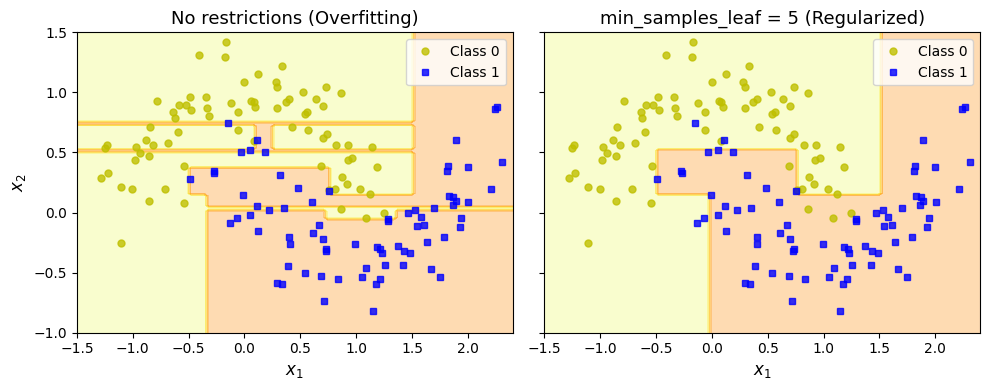

In [6]:
#시각화
import matplotlib.pyplot as plt
import numpy as np


def plot_decision_boundary(clf, X, y, axes=[-1.5, 2.4, -1.0, 1.5]):
    # 격자 좌표 생성
    x1s = np.linspace(axes[0], axes[1], 100)
    x2s = np.linspace(axes[2], axes[3], 100)
    x1, x2 = np.meshgrid(x1s, x2s)
    X_new = np.c_[x1.ravel(), x2.ravel()]

    # 예측값으로 등고선(결정 경계) 그리기
    y_pred = clf.predict(X_new).reshape(x1.shape)
    plt.contourf(x1, x2, y_pred, alpha=0.3, cmap="Wistia")

    # 데이터 산점도 그리기
    plt.plot(
        X[:, 0][y == 0],
        X[:, 1][y == 0],
        "yo",
        label="Class 0",
        markersize=5,
        alpha=0.8,
    )
    plt.plot(
        X[:, 0][y == 1],
        X[:, 1][y == 1],
        "bs",
        label="Class 1",
        markersize=5,
        alpha=0.8,
    )
    plt.axis(axes)
    plt.xlabel("$x_1$", fontsize=12)
    plt.ylabel("$x_2$", fontsize=12)
    plt.legend()


# 나란히 2개 서브플롯 생성
fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)

plt.sca(axes[0])
plot_decision_boundary(tree_clf1, X_moons, y_moons)
plt.title("No restrictions (Overfitting)", fontsize=13)

plt.sca(axes[1])
plot_decision_boundary(tree_clf2, X_moons, y_moons)
plt.title("min_samples_leaf = 5 (Regularized)", fontsize=13)
plt.ylabel("")

plt.tight_layout()
plt.show()



*   규제가 없는 결정 트리의 경우 과대적합된 것을 확인할 수 있음
*   반면, 규제를 한 결정 트리는 일반화가 더 잘 되어있음



In [8]:
#다른 랜덤 시드로 결정트리 평가하기
X_moons_test, y_moons_test = make_moons(n_samples=1000, noise=0.2, random_state=43)

print(tree_clf1.score(X_moons_test, y_moons_test))

print(tree_clf2.score(X_moons_test, y_moons_test))
#테스트 세트에서도 규제를 한 2번째 모델이 정확도가 높음을 확인할 수 있음

0.898
0.92




*   제한 없이 결정 트리를 훈련 후 불필요한 노드를 가지치기 하는 알고리즘도 존재
*   순도를 높이는 것이 큰 효과가 없다면(카이제곱 검정으로 확인) 리프 노드 위의 노드가 불필요한 것으로 보고 삭제함(우연히 향상된 것인지 보는 검정)
*   불필요한 노드가 모두 사라질 때 까지 계속해서 가지치기를 함



**6.8 회귀**



*   결정 트리는 회귀 문제에도 이용됨




In [9]:
#DecisionTreeRegressor를 이용해서 2차함수 형태의 데이터셋에서 max_depth=2인 회귀 트리 만들기
import numpy as np
from sklearn.tree import DecisionTreeRegressor

np.random.seed(42)
X_quad = np.random.rand(200,1) - 0.5
y_quad = X_quad **2 + 0.025 * np.random.randn(200,1)

tree_reg = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_reg.fit(X_quad, y_quad)

DecisionTreeRegressor(max_depth=2, random_state=42)

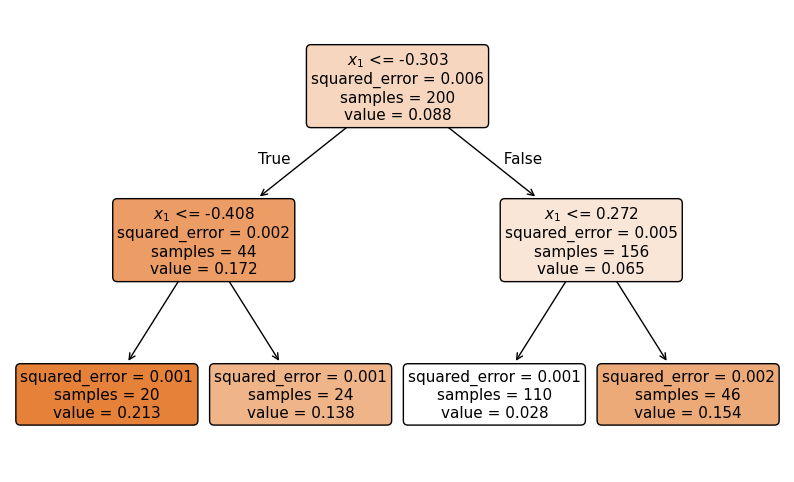

In [10]:
#시각화
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(10, 6))
plot_tree(
    tree_reg,
    feature_names=["$x_1$"],
    rounded=True,
    filled=True,
    fontsize=11
)
plt.show()